In [1]:
## import the basic modules in python
import numpy as numpy
import pandas as pd
import random as rd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## data downloaded from kaggle https://www.kaggle.com/datasets/mansoordaku/ckdisease/
kidney_df=pd.read_csv('../Datasets/kidney_disease.csv')##/Users/subasrees/Desktop/Machine_learning_practice/Datasets/kidney_disease.csv
kidney_df.describe()


,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


            age		-	age	
			bp		-	blood pressure
			sg		-	specific gravity
			al		-   	albumin
			su		-	sugar
			rbc		-	red blood cells
			pc		-	pus cell
			pcc		-	pus cell clumps
			ba		-	bacteria
			bgr		-	blood glucose random
			bu		-	blood urea
			sc		-	serum creatinine
			sod		-	sodium
			pot		-	potassium
			hemo		-	hemoglobin
			pcv		-	packed cell volume
			wc		-	white blood cell count
			rc		-	red blood cell count
			htn		-	hypertension
			dm		-	diabetes mellitus
			cad		-	coronary artery disease
			appet		-	appetite
			pe		-	pedal edema
			ane		-	anemia
			class		-	class

In [3]:
# explanation of the columns ie features taken from https://www.kaggle.com/datasets/mansoordaku/ckdisease/
kidney_df.columns=['id','age',	'blood pressure',	'specific gravity',	'albumin',	'sugar',	'red blood cells',	'pus cell',	'pus cell clumps',	'bacteria',	'blood glucose random',	'blood urea',	'serum creatinine',	'sodium',	'potassium',	'hemoglobin',	'packed cell volume',	'white blood cell count',	'red blood cell count',	'hypertension',	'diabetes mellitus',	'coronary artery disease',	'appetite',	'pedal edema',	'anemia','classification']

In [4]:
## missing values 
kidney_df.isna().sum().sort_values(ascending=False)

red blood cells            152
red blood cell count       130
white blood cell count     105
potassium                   88
sodium                      87
packed cell volume          70
pus cell                    65
hemoglobin                  52
sugar                       49
specific gravity            47
albumin                     46
blood glucose random        44
blood urea                  19
serum creatinine            17
blood pressure              12
age                          9
bacteria                     4
pus cell clumps              4
hypertension                 2
diabetes mellitus            2
coronary artery disease      2
anemia                       1
appetite                     1
pedal edema                  1
id                           0
classification               0
dtype: int64

In [5]:
## data types of features for data imputation
for i in kidney_df.columns:
    print(f"{i}:{kidney_df[i].dtype}")

id:int64
age:float64
blood pressure:float64
specific gravity:float64
albumin:float64
sugar:float64
red blood cells:object
pus cell:object
pus cell clumps:object
bacteria:object
blood glucose random:float64
blood urea:float64
serum creatinine:float64
sodium:float64
potassium:float64
hemoglobin:float64
packed cell volume:object
white blood cell count:object
red blood cell count:object
hypertension:object
diabetes mellitus:object
coronary artery disease:object
appetite:object
pedal edema:object
anemia:object
classification:object


In [6]:
import matplotlib.pylab as pylab
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix,accuracy_score
from operator import itemgetter
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.preprocessing import StandardScaler

In [7]:
## convert the datatypes of numerical datatypes given as objects
def convert_to_num(df_data,column):
    df_data[column]=pd.to_numeric(df_data[column],errors='coerce')
    
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')



In [8]:
## find the features that are originally given as objects
object_col=[]
for i in kidney_df.columns:
    if kidney_df[i].dtype=='object':
        object_col.append(i)
print(object_col)

['red blood cells', 'pus cell', 'pus cell clumps', 'bacteria', 'packed cell volume', 'white blood cell count', 'red blood cell count', 'hypertension', 'diabetes mellitus', 'coronary artery disease', 'appetite', 'pedal edema', 'anemia', 'classification']


In [9]:
## evaluate the features that are of object type
for i in object_col:
    print(i)
    print(kidney_df[i].unique())

red blood cells
[nan 'normal' 'abnormal']
pus cell
['normal' 'abnormal' nan]
pus cell clumps
['notpresent' 'present' nan]
bacteria
['notpresent' 'present' nan]
packed cell volume
['44' '38' '31' '32' '35' '39' '36' '33' '29' '28' nan '16' '24' '37' '30'
 '34' '40' '45' '27' '48' '\t?' '52' '14' '22' '18' '42' '17' '46' '23'
 '19' '25' '41' '26' '15' '21' '43' '20' '\t43' '47' '9' '49' '50' '53'
 '51' '54']
white blood cell count
['7800' '6000' '7500' '6700' '7300' nan '6900' '9600' '12100' '4500'
 '12200' '11000' '3800' '11400' '5300' '9200' '6200' '8300' '8400' '10300'
 '9800' '9100' '7900' '6400' '8600' '18900' '21600' '4300' '8500' '11300'
 '7200' '7700' '14600' '6300' '\t6200' '7100' '11800' '9400' '5500' '5800'
 '13200' '12500' '5600' '7000' '11900' '10400' '10700' '12700' '6800'
 '6500' '13600' '10200' '9000' '14900' '8200' '15200' '5000' '16300'
 '12400' '\t8400' '10500' '4200' '4700' '10900' '8100' '9500' '2200'
 '12800' '11200' '19100' '\t?' '12300' '16700' '2600' '26400' '880

In [10]:
## create a target list
kidney_target=pd.DataFrame(kidney_df['classification'])

In [11]:
import numpy as np
kidney_df['diabetes mellitus'] =kidney_df['diabetes mellitus'].replace(to_replace=['\tno','\tyes',' yes'],value=['no','yes','yes'])
kidney_df['coronary artery disease']=kidney_df['coronary artery disease'].replace(to_replace=['\tno'],value=['no'])
kidney_df['red blood cell count']=kidney_df['red blood cell count'].replace(to_replace=['\tno'],value=['no'])
kidney_df['packed cell volume']=kidney_df['packed cell volume'].replace(to_replace=['\t?','\t43'],value=[np.nan,43])
kidney_df['white blood cell count']=kidney_df['white blood cell count'].replace(to_replace=['\t6200','\t8400','\t?'],value=[6200,8400,np.nan])
kidney_target['classification']=kidney_target['classification'].replace(to_replace=['ckd','ckd\t','notckd'],value=['yes','yes','no'])

In [12]:
col_num=['packed cell volume','white blood cell count','red blood cell count']
for i in col_num:
    convert_to_num(kidney_df,i)

In [13]:
# get dummies will transform these categorical columns to sets of 0/1 columns
#df = pd.get_dummies( kidney_features , drop_first=True )
#df.head()
df=kidney_df.drop(['id','classification'],axis=1)
# Clean column names
df.columns = df.columns.str.strip()

# Split FIRST
X = df
y = kidney_target
y = kidney_target['classification'].map({'no': 0, 'yes': 1})

X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8,random_state=2026)

# Auto detect columns
numerical_columns = X_train.select_dtypes(include=['int64','float64']).columns
categorical_columns = X_train.select_dtypes(include=['object']).columns

In [14]:
y_test

144    1
391    0
319    0
217    1
128    1
      ..
134    1
297    0
213    1
383    0
306    0
Name: classification, Length: 80, dtype: int64

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [16]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean'))
])

In [17]:
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [18]:
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_columns),
    ('cat', categorical_transformer, categorical_columns)
])

In [19]:
## naives bayes, SVC and k neighbors classifiers
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [20]:
models = {
    'decision_tree': DecisionTreeClassifier(),
    'naive_bayes': GaussianNB(),
    'SVM': SVC(kernel='linear', probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=10)
}

In [21]:
## evaluation metrics
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

In [22]:
param_grids = {
    "decision_tree":{
    'model__criterion': ['gini', 'entropy', 'log_loss'],
    'model__max_depth': [None, 3, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 5, 10],
    'model__max_features': [None, 'sqrt', 'log2']
},
"naive_bayes":{'model__var_smoothing': np.logspace(-11, -7, 10)},
"SVM":{
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__class_weight': [None, 'balanced']
},
"KNN": {
    'model__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['euclidean', 'manhattan']
}}

In [23]:
model_names=['decision_tree','naive_bayes','SVM','KNN']

In [24]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)

In [25]:
best_models = {}
rank_pipe={}
for name, base_model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', base_model)
    ])

    grid = param_grids[name]

    gs = GridSearchCV(
        pipe,
        grid,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )

    gs.fit(X_train, y_train)

    print(f"\n{name}")
    print("Best CV F1:", round(gs.best_score_, 4))
    print("Best params:", gs.best_params_)

    best_models[name] = gs.best_estimator_
    rank_pipe[name] = {"pipe": pipe, "f1": round(gs.best_score_, 4)}



decision_tree
Best CV F1: 0.9926
Best params: {'model__criterion': 'gini', 'model__max_depth': 3, 'model__max_features': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

naive_bayes
Best CV F1: 0.9579
Best params: {'model__var_smoothing': 2.1544346900318867e-10}

SVM
Best CV F1: 0.9823
Best params: {'model__C': 0.1, 'model__class_weight': 'balanced'}

KNN
Best CV F1: 0.7869
Best params: {'model__metric': 'manhattan', 'model__n_neighbors': 3, 'model__weights': 'uniform'}


In [26]:
# Extract F1 scores
f1_values = {name: info['f1'] for name, info in rank_pipe.items()}

# Sort by F1 descending and take top 3
top_3 = dict(sorted(f1_values.items(), key=lambda x: x[1], reverse=True)[:3])

print(top_3)

{'decision_tree': 0.9926, 'SVM': 0.9823, 'naive_bayes': 0.9579}


In [27]:
top3_models={}
for i,j in top_3.items():
    top3_models[i]=rank_pipe[i]
    

In [28]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import precision_score
from matplotlib import gridspec
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
import scipy as sc
## let's make a helper function to plot the roc 
def makeROCplot( X , y , decFun , ax , dt = 0.5 , applyExpit = True):
    """
        * X : features
        * y : target
        * decFun : decision function of the model
        * ax : maplotlib ax to plot
        * dt = 0.5 : decision threshold to show (default 0.5), can be al ist of threshold
        * applyExpit = True : whether to apply the expit transform to thresholds (eg. for logistic regression)
    """
    
    # 1. decision_function gives you the proba for a point to be in a class
    y_score_lr_c = decFun(X)
    # 2. this calculates the ROC curve
    fpr_lr_c, tpr_lr_c, thre = roc_curve(y, y_score_lr_c)
    if applyExpit:
        thre = sc.special.expit(thre)
    # 3. finally this calculates the area under the curve
    roc_auc_lr_c = auc(fpr_lr_c, tpr_lr_c)
    #print("Area under the ROC curve",roc_auc_lr_c)

    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    ax.plot(fpr_lr_c, tpr_lr_c, lw=3, label='ROC curve\n (area = {:0.3f})'.format(roc_auc_lr_c))
    
    #this part is just to check where your probability threshold sits on the roc curve
    if isinstance(dt,float):
        dt = [dt]

    for x in dt:
        keep = np.argmin( np.abs(thre - x ) )
        ax.plot(fpr_lr_c[keep], tpr_lr_c[keep], marker='o' , linewidth = 0 ,label='threshold='+str(x))
        
    
    ax.set_xlabel('False Positive Rate', fontsize=16)
    ax.set_ylabel('True Positive Rate', fontsize=16)

    ax.legend(loc='lower right', fontsize=13)
    ax.plot([0, 1], [0, 1], color='navy', lw=3, linestyle='--')
    ax.set_aspect('equal')
    return ax
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

## let's make a helper function to plot the precision recall curve
def makePRplot( X , y , decFun , ax , dt = 0.5 , applyExpit = True):
    """
        * X : features
        * y : target
        * decFun : decision function of the model
        * ax : maplotlib ax to plot
        * dt = 0.5 : decision threshold to show (default 0.5), can be al ist of threshold
        * applyExpit = True : whether to apply the expit transform to thresholds (eg. for logistic regression)
    """
    
    # 1. decision_function gives you the proba for a point to be in a class
    probas = decFun(X)
    # 2. this calculates the precision recall curve
    precision , recall , thresholds =  precision_recall_curve(y, probas)
    if applyExpit:
        thresholds = sc.special.expit(thresholds)
    # 3. finally this calculates the average precision
    avg_precision = average_precision_score(y , probas)

    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    ax.plot(recall, precision, lw=3, label='Precision-Recall curve\n (avg = {:0.3f})'.format(avg_precision))
    
    #this part is just to check where your probability threshold sits on the roc curve
    if isinstance(dt,float):
        dt = [dt]


    for x in dt:
        keep = np.argmin( np.abs(thresholds - x ) )
        ax.plot(recall[keep], precision[keep], marker='o' , linewidth = 0 ,label='threshold='+str(x))
        
    
    ax.set_xlabel('Recall', fontsize=16)
    ax.set_ylabel('Precision', fontsize=16)
    ax.legend(loc='lower right', fontsize=13)
    
    ax.set_aspect('equal')
    return ax



Classification report for decision_tree:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93        30
           1       0.94      0.98      0.96        50

    accuracy                           0.95        80
   macro avg       0.95      0.94      0.95        80
weighted avg       0.95      0.95      0.95        80



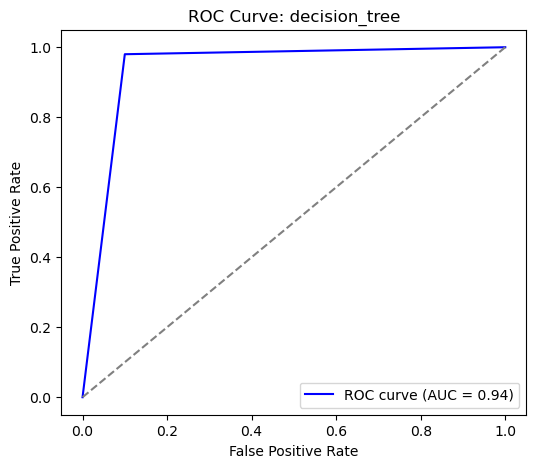

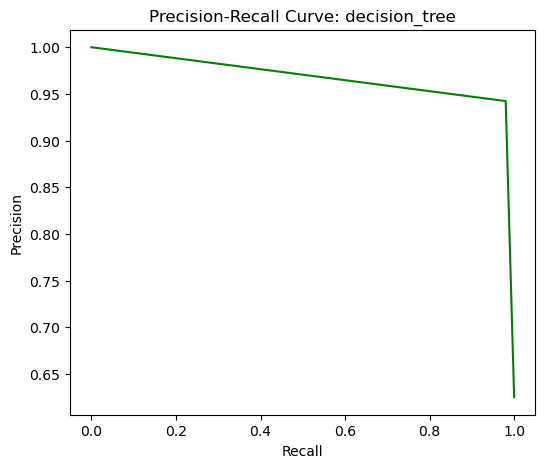


Classification report for SVM:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90        30
           1       0.96      0.92      0.94        50

    accuracy                           0.93        80
   macro avg       0.92      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80



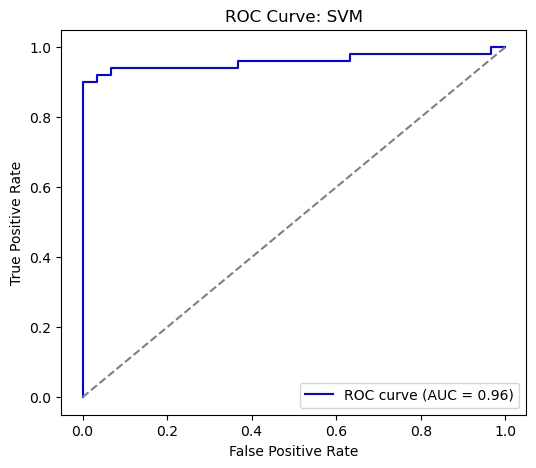

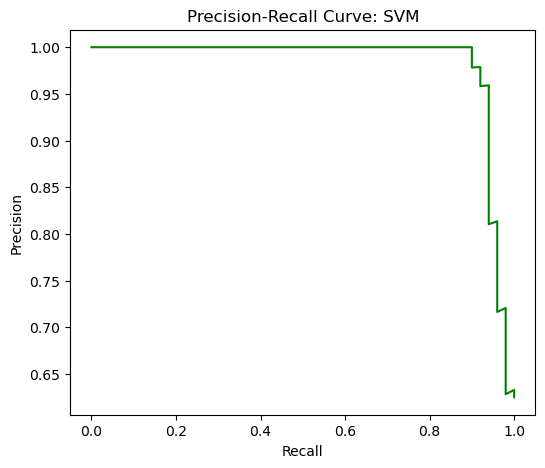


Classification report for naive_bayes:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        30
           1       1.00      0.92      0.96        50

    accuracy                           0.95        80
   macro avg       0.94      0.96      0.95        80
weighted avg       0.96      0.95      0.95        80



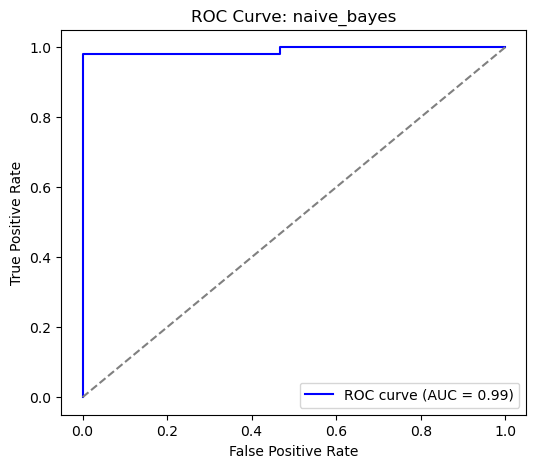

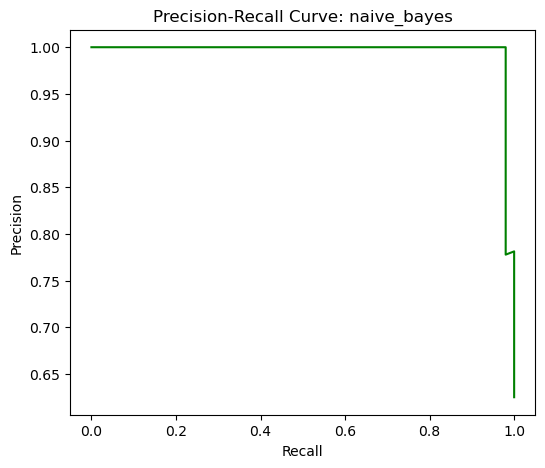

In [30]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, classification_report
import matplotlib.pyplot as plt

for name, model_dict in top3_models.items():
    model_pipe = model_dict['pipe']
    model_pipe.fit(X_train, y_train)
    # Make predictions
    y_pred = model_pipe.predict(X_test)
    print(f"\nClassification report for {name}:")
    print(classification_report(y_test, y_pred))
    
    # Get scores for ROC/PR plots
    if hasattr(model_pipe, "decision_function"):
        y_scores = model_pipe.decision_function(X_test)
    else:  # fallback to predict_proba
        y_scores = model_pipe.predict_proba(X_test)[:, 1]
    
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0,1], [0,1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve: {name}')
    plt.legend()
    plt.show()
    
    # Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    plt.figure(figsize=(6,5))
    plt.plot(recall, precision, color='green')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve: {name}')
    plt.show()

In [36]:
for name, model_dict in top3_models.items():
    pipe = model_dict['pipe']
    print(f"Fitting {name}...")
    pipe.fit(X_train, y_train)  # fit the pipeline

Fitting decision_tree...
Fitting SVM...
Fitting naive_bayes...


In [37]:
from sklearn.inspection import permutation_importance

for name, model_dict in top3_models.items():
    pipe = model_dict['pipe']
    r = permutation_importance(pipe, X_test, y_test,
                               n_repeats=30,
                               random_state=2026)
    print(f"\nPermutation Importances for {name}:")
    for i in r.importances_mean.argsort()[::-1]:
        if r.importances_mean[i] - 2 * r.importances_std[i] > 0:
            print(f"{X_test.columns[i]:<20} {r.importances_mean[i]:.3f} +/- {r.importances_std[i]:.3f}")


Permutation Importances for decision_tree:
specific gravity     0.164 +/- 0.029
hypertension         0.119 +/- 0.026
packed cell volume   0.118 +/- 0.022
serum creatinine     0.103 +/- 0.025
hemoglobin           0.072 +/- 0.023
blood urea           0.042 +/- 0.013

Permutation Importances for SVM:

Permutation Importances for naive_bayes:
diabetes mellitus    0.141 +/- 0.034
hypertension         0.128 +/- 0.032
pedal edema          0.091 +/- 0.025
albumin              0.075 +/- 0.026
pus cell             0.066 +/- 0.023
appetite             0.055 +/- 0.022
sugar                0.045 +/- 0.021
pus cell clumps      0.033 +/- 0.014
